# Paper Figures — Role Probe (§3, Appendix C)

Minimal notebook that produces only the figures and tables used in the paper's
role-probe sections:

- **Table 2** (§3.2): standard role-probe accuracy, transcript-held-out.
- **Table 3** (Appendix C.2): within-transcript 2/3 → 1/3 split.
- **Table 4** (Appendix C.2): first-half → second-half split.
- **Figure 2** (§3.3): quote turns flip the probe. Panel A: per-model selectivity bars. Panel B: per-turn P(true speaker) on one transcript.
- **Figure 9** (Appendix C.2): conditional transfer across splits.

Bar-chart versions of Tables 2/3/4 are also rendered as sanity-check visuals.

**Inputs** (under `speaker-tracking/data/experiments/mean_pooling/`):
- `analysis/<tag>/exp_<exp>_linear_probe.json`
- `analysis/<tag>/exp_<exp>_probe_random_2_3.json`
- `analysis/<tag>/exp_<exp>_probe_first_vs_second.json`
- `analysis/<tag>/exp_agreement_pivot_probe_pivot_window.json`
- `analysis/<tag>/exp_agreement_pivot_probe_pivot_halves.json`
- `analysis/<tag>/exp_quote_intrusion_probe_quote.json`
- `embeddings/<tag>/exp_quote_intrusion_mean_embeddings.ckpt.jsonl` (for Figure 2B)

**Outputs**: `speaker-tracking/data/experiments/mean_pooling/plots/paper_figures/`.

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

def _find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    markers = ("pyproject.toml", ".git", "README.md")
    for parent in [cur, *cur.parents]:
        if (parent / "speaker-tracking").is_dir() and any(
            (parent / m).exists() for m in markers
        ):
            return parent
    return start.resolve()

REPO = _find_repo_root(Path.cwd())
MEAN_ROOT = REPO / "speaker-tracking/data/experiments/mean_pooling"
EMBED_ROOT = MEAN_ROOT / "embeddings"
FIG_DIR = MEAN_ROOT / "plots/paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
assert MEAN_ROOT.is_dir(), f"MEAN_ROOT does not exist: {MEAN_ROOT}"
REPO, FIG_DIR

(PosixPath('/Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation'),
 PosixPath('/Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/plots/paper_figures'))

In [2]:
MODEL_TAGS = ["llama31_8b", "gemma2_9b", "qwen25_7b", "olmo3_7b", "gemma3_4b"]
MODEL_LABEL = {
    "llama31_8b": "Llama 3.1 8B Instruct",
    "gemma2_9b": "Gemma 2 9B IT",
    "qwen25_7b": "Qwen 2.5 7B Instruct",
    "olmo3_7b": "OLMo 3 7B Instruct",
    "gemma3_4b": "Gemma 3 4B IT",
}
EXPERIMENTS = [
    "agreement_pivot",
    "similar_neutral",
    "similar_polarize",
    "quote_intrusion",
    "distinct_names",
]
EXP_LABEL = {
    "agreement_pivot": "Agreement Pivot",
    "similar_neutral": "Similar (neutral)",
    "similar_polarize": "Similar (polarize)",
    "quote_intrusion": "Quote Intrusion",
    "distinct_names": "Distinct Names",
}
PROBE = "logreg_l2"

## 2. Data loaders

In [3]:
def load_json(path):
    path = Path(path)
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as fh:
        return json.load(fh)

def analysis_path(tag, exp, suffix):
    return MEAN_ROOT / f"analysis/{tag}/exp_{exp}_{suffix}.json"

def embedding_path(tag, exp):
    return EMBED_ROOT / tag / f"exp_{exp}_mean_embeddings.ckpt.jsonl"

In [4]:
def collect_standard_probe():
    """Aggregate standard probe: one row per (tag, exp) from `linear_probe.json`."""
    rows = []
    for tag in MODEL_TAGS:
        for exp in EXPERIMENTS:
            d = load_json(analysis_path(tag, exp, "linear_probe"))
            if d is None:
                continue
            for _mid, blob in d.get("results_by_model", {}).items():
                role = blob.get("role", {})
                agg = role.get("aggregate", {}).get(PROBE, {})
                ctrl = role.get("aggregate_control", {}).get(PROBE, {})
                if not agg:
                    continue
                rows.append({
                    "tag": tag, "exp": exp,
                    "acc_mean": agg.get("accuracy", {}).get("mean"),
                    "acc_std":  agg.get("accuracy", {}).get("std"),
                    "ctrl_mean": ctrl.get("accuracy", {}).get("mean"),
                    "ctrl_std":  ctrl.get("accuracy", {}).get("std"),
                })
    return pd.DataFrame(rows)

def collect_conditional(suffix, value_key="accuracy"):
    """Aggregate a conditional probe (per-transcript mean): one row per (tag, exp)."""
    rows = []
    for tag in MODEL_TAGS:
        for exp in EXPERIMENTS:
            d = load_json(analysis_path(tag, exp, suffix))
            if d is None:
                continue
            for _mid, blob in d.get("results_by_model", {}).items():
                vals, ctrls = [], []
                for _tid, tblob in blob.get("per_transcript", {}).items():
                    role = tblob.get("role")
                    if not isinstance(role, dict):
                        continue
                    m = role.get("metrics_by_probe", {}).get(PROBE, {}) or {}
                    cm = (role.get("control_metrics_by_probe") or {}).get(PROBE, {}) or {}
                    if m.get(value_key) is not None:
                        vals.append(float(m[value_key]))
                    if cm.get(value_key) is not None:
                        ctrls.append(float(cm[value_key]))
                if not vals:
                    continue
                rows.append({
                    "tag": tag, "exp": exp,
                    "n_transcripts": len(vals),
                    "acc_mean": float(np.mean(vals)),
                    "acc_std":  float(np.std(vals)),
                    "ctrl_mean": float(np.mean(ctrls)) if ctrls else None,
                    "ctrl_std":  float(np.std(ctrls)) if ctrls else None,
                })
    return pd.DataFrame(rows)

def collect_single_exp(suffix, exp):
    """Like `collect_conditional` but restricted to one experiment."""
    rows = []
    for tag in MODEL_TAGS:
        d = load_json(analysis_path(tag, exp, suffix))
        if d is None:
            continue
        for _mid, blob in d.get("results_by_model", {}).items():
            vals, ctrls = [], []
            for _tid, tblob in blob.get("per_transcript", {}).items():
                role = tblob.get("role")
                if not isinstance(role, dict):
                    continue
                m = role.get("metrics_by_probe", {}).get(PROBE, {}) or {}
                cm = (role.get("control_metrics_by_probe") or {}).get(PROBE, {}) or {}
                if m.get("accuracy") is not None:
                    vals.append(float(m["accuracy"]))
                if cm.get("accuracy") is not None:
                    ctrls.append(float(cm["accuracy"]))
            if vals:
                rows.append({
                    "tag": tag, "split": suffix, "exp": exp,
                    "acc_mean": float(np.mean(vals)),
                    "acc_std":  float(np.std(vals)),
                    "ctrl_mean": float(np.mean(ctrls)) if ctrls else None,
                    "ctrl_std":  float(np.std(ctrls)) if ctrls else None,
                    "n_transcripts": len(vals),
                })
    return pd.DataFrame(rows)

In [5]:
std_df         = collect_standard_probe()
rand23_df      = collect_conditional("probe_random_2_3")
first_second_df = collect_conditional("probe_first_vs_second")
pivot_window_df = collect_single_exp("probe_pivot_window", "agreement_pivot")
pivot_halves_df = collect_single_exp("probe_pivot_halves", "agreement_pivot")
quote_df        = collect_single_exp("probe_quote",        "quote_intrusion")
print("shapes:",
      "std=", std_df.shape,
      "rand23=", rand23_df.shape,
      "first_second=", first_second_df.shape,
      "pivot_window=", pivot_window_df.shape,
      "pivot_halves=", pivot_halves_df.shape,
      "quote=", quote_df.shape)

shapes: std= (5, 6) rand23= (5, 7) first_second= (5, 7) pivot_window= (1, 8) pivot_halves= (1, 8) quote= (1, 8)


## 3. Tables 2, 3, 4

Paper tables are numeric. Each dataframe below is the full (`tag`, `exp`) grid; the paper
reports only the Llama-3.1-8B rows but we keep the full grid so cross-model rows are
available for the appendix / revisions.

In [6]:
print("Table 2 — Role probe accuracy, transcript-held-out (§3.2)")
std_df.round(3)

Table 2 — Role probe accuracy, transcript-held-out (§3.2)


,tag,exp,acc_mean,acc_std,ctrl_mean,ctrl_std
0,llama31_8b,agreement_pivot,0.681,0.026,0.491,0.011
1,llama31_8b,similar_neutral,0.608,0.024,0.494,0.033
2,llama31_8b,similar_polarize,0.652,0.037,0.507,0.027
3,llama31_8b,quote_intrusion,0.619,0.006,0.497,0.011
4,llama31_8b,distinct_names,0.626,0.012,0.501,0.010


In [7]:
print("Table 3 — Role probe accuracy, within-transcript random 2/3 vs 1/3 (Appendix C.2)")
rand23_df.round(3)

Table 3 — Role probe accuracy, within-transcript random 2/3 vs 1/3 (Appendix C.2)


,tag,exp,n_transcripts,acc_mean,acc_std,ctrl_mean,ctrl_std
0,llama31_8b,agreement_pivot,20,0.557,0.112,0.485,0.029
1,llama31_8b,similar_neutral,20,0.475,0.075,0.480,0.030
2,llama31_8b,similar_polarize,20,0.604,0.151,0.484,0.034
3,llama31_8b,quote_intrusion,20,0.464,0.065,0.477,0.031
4,llama31_8b,distinct_names,20,0.478,0.063,0.462,0.033


In [8]:
print("Table 4 — Role probe accuracy, first-half → second-half (Appendix C.2)")
first_second_df.round(3)

Table 4 — Role probe accuracy, first-half → second-half (Appendix C.2)


,tag,exp,n_transcripts,acc_mean,acc_std,ctrl_mean,ctrl_std
0,llama31_8b,agreement_pivot,20,0.625,0.112,0.502,0.048
1,llama31_8b,similar_neutral,20,0.588,0.064,0.476,0.051
2,llama31_8b,similar_polarize,20,0.642,0.171,0.489,0.063
3,llama31_8b,quote_intrusion,20,0.572,0.060,0.497,0.045
4,llama31_8b,distinct_names,20,0.583,0.062,0.496,0.046


## 4. Bar-chart versions of Tables 2/3/4 (sanity visuals, not in paper)

Same numbers as the tables; visual summary with shuffle-control markers.

In [9]:
def plot_grouped_bars(df, title="", ylabel="Role accuracy", savename=None):
    if df.empty:
        print("(empty)")
        return None
    df = df.copy()
    df["model"] = df["tag"].map(MODEL_LABEL)
    df["exp_label"] = df["exp"].map(EXP_LABEL)
    order_tags = [MODEL_LABEL[t] for t in MODEL_TAGS if MODEL_LABEL[t] in set(df["model"])]
    order_exps = [EXP_LABEL[e] for e in EXPERIMENTS if EXP_LABEL[e] in set(df["exp_label"])]

    n_m = len(order_tags); n_e = len(order_exps)
    width = 0.8 / max(n_m, 1)
    x = np.arange(n_e)
    fig, ax = plt.subplots(figsize=(max(7, 1.3 * n_e), 4.2))
    palette = sns.color_palette("tab10", n_m)
    for i, m in enumerate(order_tags):
        sub = df[df["model"] == m].set_index("exp_label").reindex(order_exps)
        xs = x + (i - (n_m - 1) / 2) * width
        ax.bar(xs, sub["acc_mean"], width, yerr=sub["acc_std"], label=m,
               color=palette[i], alpha=0.78,
               capsize=3, edgecolor="black", linewidth=0.4,
               ecolor="black", error_kw=dict(alpha=0.9))
        if "ctrl_mean" in sub.columns:
            ax.errorbar(xs, sub["ctrl_mean"],
                        yerr=sub["ctrl_std"] if "ctrl_std" in sub.columns else None,
                        fmt="_", color="0.35", ecolor="0.35",
                        lw=1.2, capsize=3, markersize=10, alpha=0.85)
    ax.axhline(0.5, color="0.6", ls=":", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(order_exps, rotation=15, ha="right")
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False, ncol=2, fontsize=9)
    sns.despine(ax=ax)
    fig.tight_layout()
    if savename:
        out = FIG_DIR / f"{savename}.pdf"
        fig.savefig(out); fig.savefig(out.with_suffix(".png"))
        print(f"saved {out}")
    return fig

saved /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/plots/paper_figures/table2_role_probe_standard.pdf


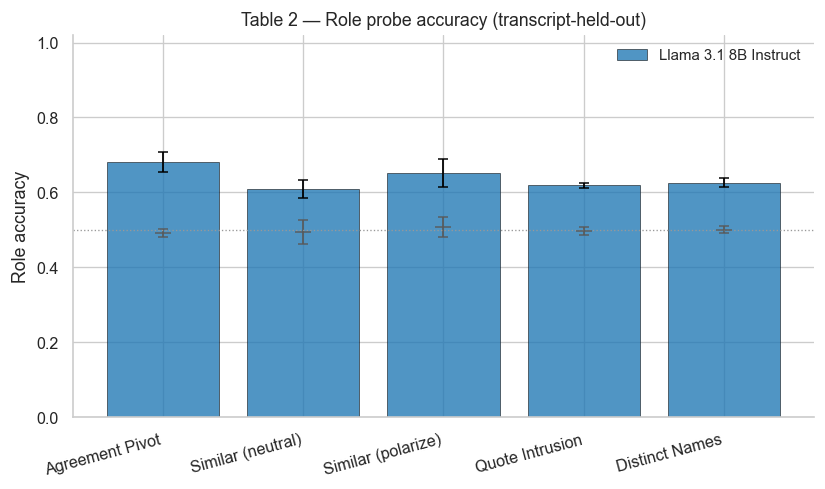

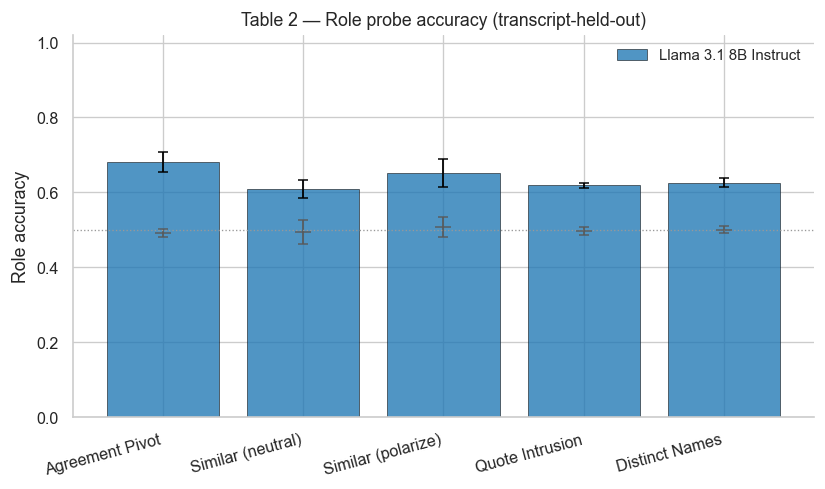

In [10]:
plot_grouped_bars(
    std_df,
    title="Table 2 — Role probe accuracy (transcript-held-out)",
    savename="table2_role_probe_standard",
)

saved /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/plots/paper_figures/table3_role_probe_within_2_3.pdf


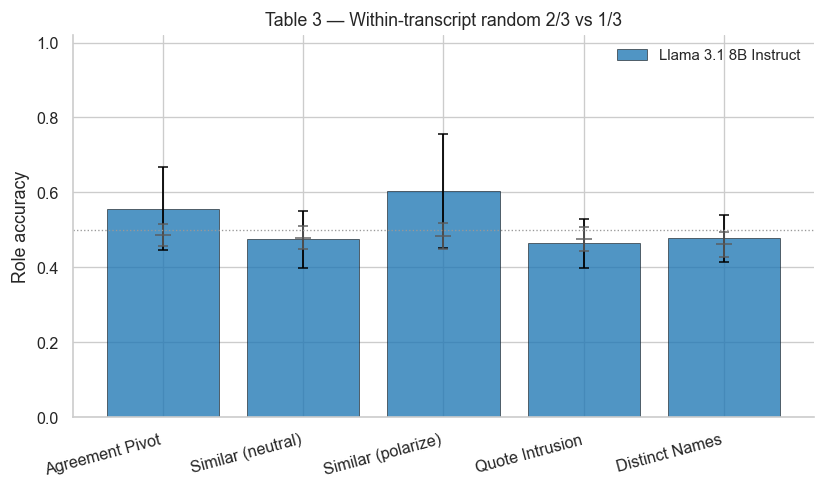

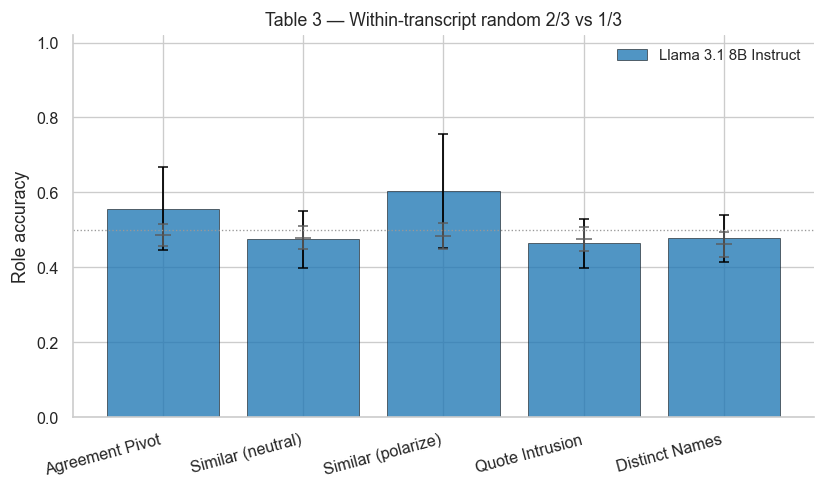

In [11]:
plot_grouped_bars(
    rand23_df,
    title="Table 3 — Within-transcript random 2/3 vs 1/3",
    savename="table3_role_probe_within_2_3",
)

saved /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/plots/paper_figures/table4_role_probe_first_vs_second.pdf


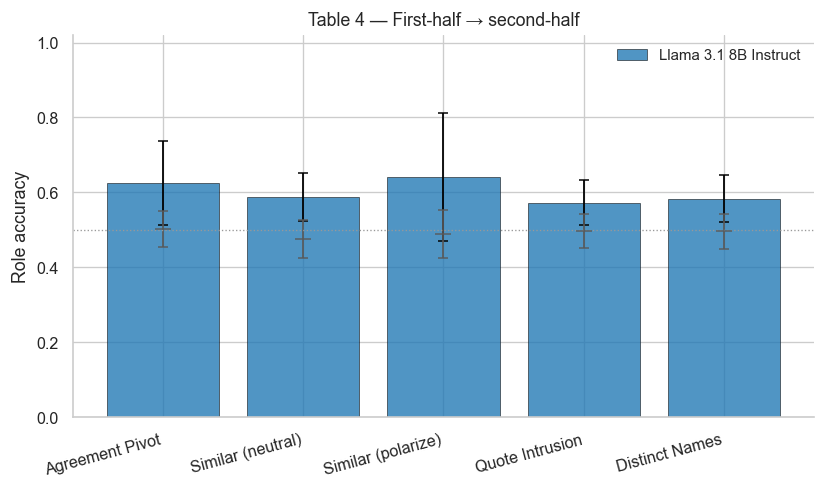

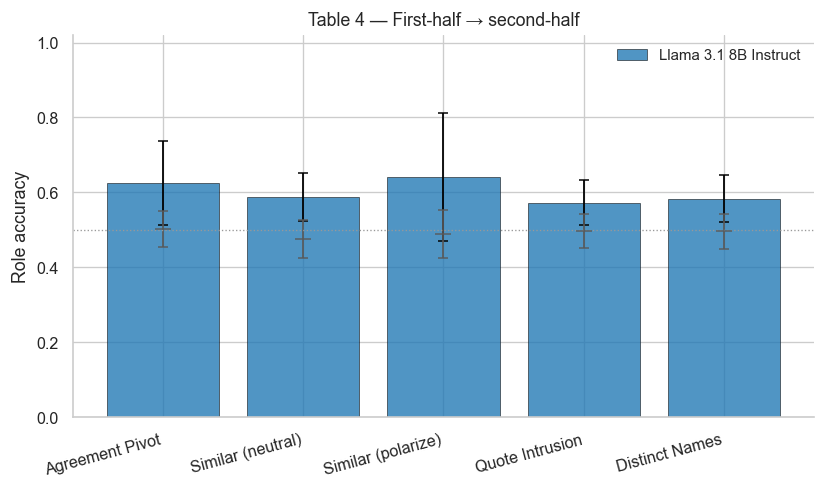

In [12]:
plot_grouped_bars(
    first_second_df,
    title="Table 4 — First-half → second-half",
    savename="table4_role_probe_first_vs_second",
)

## 5. Figure 9 (Appendix C.2) — Conditional transfer across splits

Four bars: agreement-pivot outside→inside window, agreement-pivot window halves,
quote-intrusion no-quote→quote, and (averaged over experiments) within-transcript
random 2/3 → 1/3 baseline.

In [13]:
pieces = [
    pivot_window_df.assign(condition="Agreement pivot: outside→inside window"),
    pivot_halves_df.assign(condition="Agreement pivot: window first→second half"),
    quote_df.assign(condition="Quote intrusion: no-quote→quote"),
]
if not rand23_df.empty:
    rand_summary = (
        rand23_df.groupby("tag", as_index=False)
                 .agg(acc_mean=("acc_mean", "mean"), acc_std=("acc_std", "mean"))
                 .assign(exp="all",
                         condition="Within-transcript random 2/3→1/3 (all exps, averaged)")
    )
    pieces.append(rand_summary)

all_cond = pd.concat(pieces, ignore_index=True, sort=False)
all_cond

,tag,split,exp,acc_mean,acc_std,ctrl_mean,ctrl_std,n_transcripts,condition
0,llama31_8b,probe_pivot_window,agreement_pivot,0.659091,0.159739,0.527273,0.156406,20.0,Agreement pivot: outside→inside window
1,llama31_8b,probe_pivot_halves,agreement_pivot,0.475000,0.121049,0.491667,0.064010,20.0,Agreement pivot: window first→second half
2,llama31_8b,probe_quote,quote_intrusion,0.375940,0.130093,0.494726,0.124314,20.0,Quote intrusion: no-quote→quote
3,llama31_8b,NaN,all,0.515550,0.093214,NaN,NaN,NaN,"Within-transcript random 2/3→1/3 (all exps, av..."


saved /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/plots/paper_figures/figure9_conditional_transfer.pdf


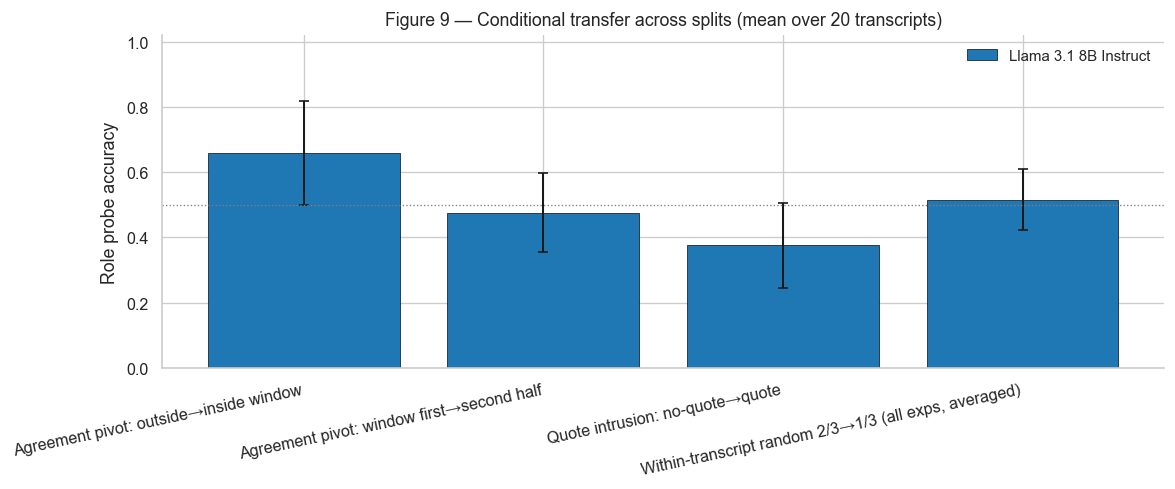

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.2))
pivot_for_plot = all_cond.dropna(subset=["condition"]).copy()
pivot_for_plot["model"] = pivot_for_plot["tag"].map(MODEL_LABEL)
conditions_order = list(pivot_for_plot["condition"].dropna().unique())
tags_present = [t for t in MODEL_TAGS if MODEL_LABEL[t] in pivot_for_plot["model"].values]
x = np.arange(len(conditions_order))
n_m = len(tags_present); width = 0.8 / max(n_m, 1)
palette = sns.color_palette("tab10", n_m)
for i, tag in enumerate(tags_present):
    sub = (pivot_for_plot[pivot_for_plot["tag"] == tag]
           .set_index("condition").reindex(conditions_order))
    xs = x + (i - (n_m - 1) / 2) * width
    ax.bar(xs, sub["acc_mean"], width, yerr=sub["acc_std"],
           label=MODEL_LABEL[tag], color=palette[i],
           capsize=3, edgecolor="black", linewidth=0.4)
ax.set_xticks(x); ax.set_xticklabels(conditions_order, rotation=12, ha="right")
ax.axhline(0.5, color="grey", ls=":", lw=0.8)
ax.set_ylim(0, 1.02)
ax.set_ylabel("Role probe accuracy")
ax.set_title("Figure 9 — Conditional transfer across splits (mean over 20 transcripts)")
ax.legend(frameon=False, ncol=2, fontsize=9)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure9_conditional_transfer.pdf")
fig.savefig(FIG_DIR / "figure9_conditional_transfer.png")
print(f"saved {FIG_DIR/'figure9_conditional_transfer.pdf'}")

## 6. Figure 2 (§3.3) — Quote turns flip the probe

**Panel A.** Per-model selectivity = accuracy − shuffled-label control. Two bars per
model: standard probe (green) vs no-quote → quote transfer probe (gold). Selectivity
gap is annotated over each model; dashed line marks the shuffle control (0).

**Panel B.** Per-turn P(true speaker) on one transcript (`quote_intrusion_001`) for
the focus model (Llama-3.1-8B). Non-quote turns: 10-fold out-of-fold predictions from
logreg_l2 fit on non-quote turns. Quote turns: predictions from a probe trained on
all non-quote turns, evaluated on quote turns. Seed chosen as the one with highest
non-quote CV accuracy (this is a visualization choice, not a claim from the main
aggregate results).

In [15]:
EXP = "quote_intrusion"
FOCUS_TAG = "llama31_8b"
FOCUS_TRANSCRIPT = "quote_intrusion_001"

C_STD = "#2E8B57"
C_QUOTE = "#F7B500"
FS_TITLE = 15
FS_LABEL = 12.5
FS_TICK = 11
FS_LEGEND = 10.5
FS_ANNOT = 10.5

def _row(df, tag, exp=EXP):
    if df is None or df.empty:
        return {"acc_mean": np.nan, "acc_std": 0.0, "ctrl_mean": np.nan, "n": 0}
    sub = df[(df["tag"] == tag) & (df["exp"] == exp)]
    if sub.empty:
        return {"acc_mean": np.nan, "acc_std": 0.0, "ctrl_mean": np.nan, "n": 0}
    r = sub.iloc[0]
    return {
        "acc_mean": float(r["acc_mean"]) if pd.notna(r["acc_mean"]) else np.nan,
        "acc_std":  float(r["acc_std"])  if pd.notna(r["acc_std"])  else 0.0,
        "ctrl_mean": float(r["ctrl_mean"]) if pd.notna(r.get("ctrl_mean")) else np.nan,
        "n": int(r["n_transcripts"]) if "n_transcripts" in r else 0,
    }

def _row_quote(tag):
    if quote_df is None or quote_df.empty:
        return {"acc_mean": np.nan, "acc_std": 0.0, "ctrl_mean": np.nan, "n": 0}
    sub = quote_df[quote_df["tag"] == tag]
    if sub.empty:
        return {"acc_mean": np.nan, "acc_std": 0.0, "ctrl_mean": np.nan, "n": 0}
    r = sub.iloc[0]
    return {
        "acc_mean": float(r["acc_mean"]) if pd.notna(r["acc_mean"]) else np.nan,
        "acc_std":  float(r["acc_std"])  if pd.notna(r["acc_std"])  else 0.0,
        "ctrl_mean": float(r["ctrl_mean"]) if pd.notna(r.get("ctrl_mean")) else np.nan,
        "n": int(r["n_transcripts"]) if "n_transcripts" in r else 0,
    }

def _sel(row):
    a, c = row.get("acc_mean"), row.get("ctrl_mean")
    if a is None or c is None or np.isnan(a) or np.isnan(c):
        return np.nan
    return float(a) - float(c)

conditions_bar = [
    ("Standard",         C_STD,   lambda t: _row(std_df, t)),
    ("No-quote → quote", C_QUOTE, _row_quote),
]
tags_present = [t for t in MODEL_TAGS
                if any(not np.isnan(fn(t)["acc_mean"]) for _, _, fn in conditions_bar)]
tags_present

['llama31_8b']

In [16]:
import re as _re
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

_QUOTE_RE = _re.compile(r"'[^'\n]{10,}'")
def _is_quote_turn(text):
    m = _QUOTE_RE.search(text or "")
    return bool(m and " " in m.group(0)[1:-1])

def _load_transcript_turns(tag, exp, transcript_id, variant="base"):
    path = embedding_path(tag, exp)
    rows = []
    if not path.exists():
        return rows
    with path.open("r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                r = json.loads(line)
            except Exception:
                continue
            if r.get("transcript_id") == transcript_id and r.get("variant") == variant:
                rows.append(r)
    rows.sort(key=lambda r: int(r.get("turn_id", -1)))
    return rows

def _new_probe():
    return make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        LogisticRegression(C=1.0, penalty="l2", solver="lbfgs", max_iter=20000),
    )

Seed sweep for quote_intrusion_001 on llama31_8b:
  seed=0  non-quote acc=0.464  quote flip rate=0.826
  seed=1  non-quote acc=0.454  quote flip rate=0.826
  seed=2  non-quote acc=0.454  quote flip rate=0.826
  seed=3  non-quote acc=0.464  quote flip rate=0.826
  seed=4  non-quote acc=0.526  quote flip rate=0.826  <-- used
saved /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/plots/paper_figures/figure2_quote_intrusion.pdf


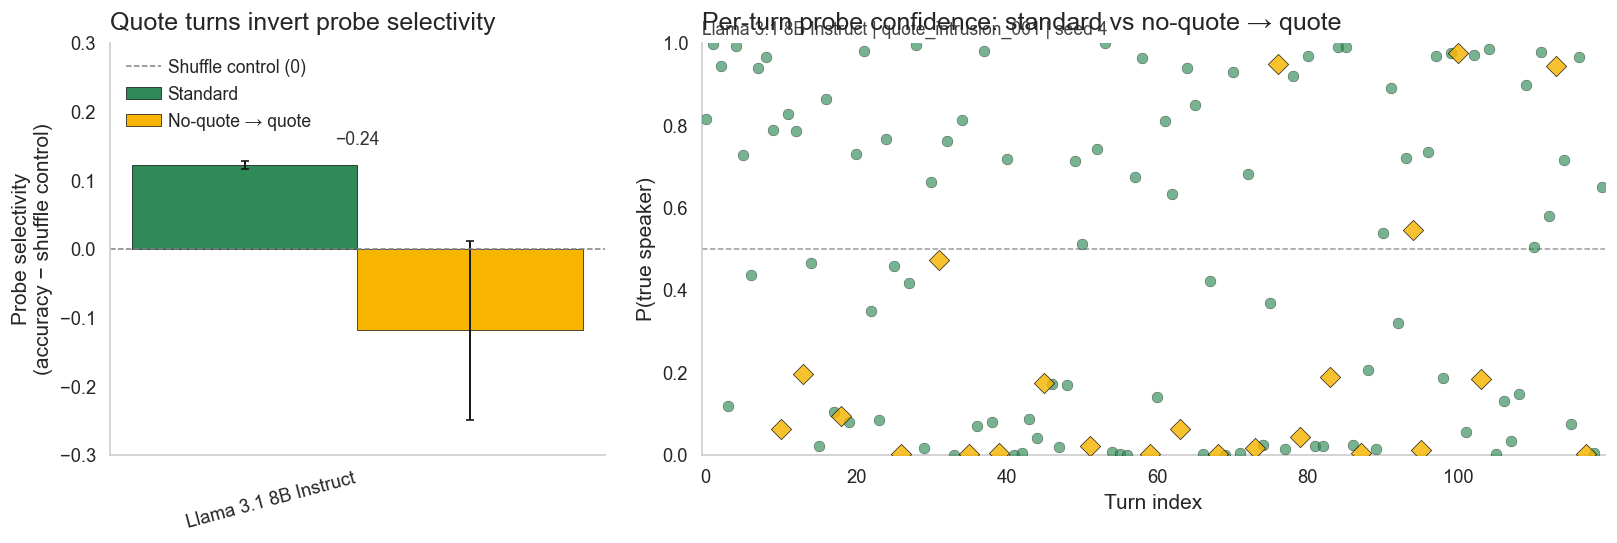

In [17]:
fig, (axA, axB) = plt.subplots(
    1, 2, figsize=(13.6, 5.2), gridspec_kw={"width_ratios": [0.85, 1.55]},
)

# ---------- Panel A: cross-model selectivity bars ----------
n_cond = len(conditions_bar)
width = 0.8 / n_cond
x = np.arange(len(tags_present))
for i, (label, color, fn) in enumerate(conditions_bar):
    sels = np.array([_sel(fn(t)) for t in tags_present])
    stds = np.array([fn(t)["acc_std"] for t in tags_present])
    offsets = x + (i - (n_cond - 1) / 2) * width
    axA.bar(offsets, sels, width, yerr=stds,
            color=color, edgecolor="black", linewidth=0.4, capsize=2.5,
            label=label)

std_fn   = conditions_bar[0][2]
quote_fn = conditions_bar[1][2]
for j, t in enumerate(tags_present):
    s_sel = _sel(std_fn(t))
    q_sel = _sel(quote_fn(t))
    if np.isfinite(s_sel) and np.isfinite(q_sel):
        top = max(s_sel, q_sel) + 0.03
        axA.annotate(f"−{(s_sel - q_sel):.2f}", xy=(x[j], top),
                     ha="center", fontsize=FS_ANNOT, color="#333")

axA.axhline(0.0, ls="--", color="grey", lw=0.9, label="Shuffle control (0)")
axA.set_xticks(x)
axA.set_xticklabels([MODEL_LABEL.get(t, t) for t in tags_present],
                    rotation=15, ha="right", fontsize=FS_TICK)
axA.set_ylim(-0.3, 0.3)
axA.set_ylabel("Probe selectivity\n(accuracy − shuffle control)", fontsize=FS_LABEL)
axA.set_title("Quote turns invert probe selectivity",
              fontsize=FS_TITLE, loc="left", pad=8)
axA.legend(frameon=False, fontsize=FS_LEGEND, loc="upper left",
           ncol=1, columnspacing=1.0, handletextpad=0.4)
axA.tick_params(axis="y", labelsize=FS_TICK)
axA.grid(False)
sns.despine(ax=axA)

# ---------- Panel B: within-transcript per-turn P(true speaker) ----------
focus_tag = FOCUS_TAG if FOCUS_TAG in tags_present else (tags_present[0] if tags_present else None)
BEST_SEED = None
if focus_tag is not None:
    rows = _load_transcript_turns(focus_tag, EXP, FOCUS_TRANSCRIPT, variant="base")
    if rows:
        turn_ids = np.array([int(r["turn_id"]) for r in rows])
        speakers = np.array([r["speaker"] for r in rows])
        texts = [r["text"] for r in rows]
        X = np.array([r["vector"] for r in rows], dtype=np.float32)
        is_quote = np.array([_is_quote_turn(t) for t in texts])

        classes = sorted(set(speakers))
        pos = "Alice" if "Alice" in classes else classes[0]
        y = (speakers == pos).astype(int)
        X_nq, y_nq = X[~is_quote], y[~is_quote]
        X_q = X[is_quote]

        n_splits_std = min(10, max(2, int(np.min(np.bincount(y)))))
        SEED_GRID = list(range(5))
        best = None
        seed_sweep = []
        for s in SEED_GRID:
            skf_std = StratifiedKFold(n_splits=n_splits_std, shuffle=True, random_state=s)
            p_all = cross_val_predict(_new_probe(), X, y, cv=skf_std, method="predict_proba")[:, 1]
            p_nq = p_all[~is_quote]
            probe_s = _new_probe().fit(X_nq, y_nq)
            p_q = probe_s.predict_proba(X_q)[:, 1] if len(X_q) else np.array([])
            nq_acc = float(np.mean((p_nq > 0.5) == y[~is_quote].astype(bool)))
            p_true_q = (y[is_quote] * p_q + (1 - y[is_quote]) * (1.0 - p_q)) if len(p_q) else np.array([])
            flip = float(np.mean(p_true_q < 0.5)) if p_true_q.size else float("nan")
            seed_sweep.append({"seed": s, "nq_acc": nq_acc, "quote_flip_rate": flip})
            if best is None or nq_acc > best["nq_acc"]:
                best = {"seed": s, "nq_acc": nq_acc, "quote_flip_rate": flip,
                        "p_nq": p_nq, "p_q": p_q}
        BEST_SEED = best["seed"]
        print(f"Seed sweep for {FOCUS_TRANSCRIPT} on {focus_tag}:")
        for row in seed_sweep:
            marker = "  <-- used" if row["seed"] == BEST_SEED else ""
            print(f"  seed={row['seed']}  non-quote acc={row['nq_acc']:.3f}  quote flip rate={row['quote_flip_rate']:.3f}{marker}")

        p_full = np.empty(len(rows), dtype=float)
        p_full[~is_quote] = best["p_nq"]
        if len(X_q):
            p_full[is_quote] = best["p_q"]
        p_true = np.where(y == 1, p_full, 1.0 - p_full)

        axB.axhline(0.5, ls="--", color="grey", lw=0.9, alpha=0.8,
                    label="Decision boundary (0.5)")
        axB.scatter(turn_ids[~is_quote], p_true[~is_quote],
                    color=C_STD, s=42, alpha=0.65, edgecolor="black",
                    linewidth=0.25, zorder=3,
                    label=f"Standard (non-quote; n = {int((~is_quote).sum())})")
        axB.scatter(turn_ids[is_quote], p_true[is_quote],
                    color=C_QUOTE, s=74, marker="D", alpha=0.82,
                    edgecolor="black", linewidth=0.45, zorder=4,
                    label=f"No-quote → quote (quote; n = {int(is_quote.sum())})")
        axB.set_xlim(-0.5, len(turn_ids) - 0.5)
        axB.set_ylim(0.0, 1.0)
        axB.set_xlabel("Turn index", fontsize=FS_LABEL)
        axB.set_ylabel("P(true speaker)", fontsize=FS_LABEL)
        axB.set_title("Per-turn probe confidence: standard vs no-quote → quote",
                      fontsize=FS_TITLE, loc="left", pad=8)
        axB.text(0.0, 1.01,
                 f"{MODEL_LABEL.get(focus_tag, focus_tag)} | {FOCUS_TRANSCRIPT} | seed {BEST_SEED}",
                 transform=axB.transAxes, ha="left", va="bottom",
                 fontsize=FS_LEGEND, color="#444")
        axB.tick_params(axis="both", labelsize=FS_TICK)
        axB.grid(False)
        sns.despine(ax=axB)
    else:
        axB.text(0.5, 0.5, f"No embeddings found for {FOCUS_TRANSCRIPT}",
                 transform=axB.transAxes, ha="center", va="center", fontsize=12)
        axB.axis("off")

fig.tight_layout(pad=1.1, w_pad=1.8)
fig.subplots_adjust(top=0.84, bottom=0.18)
out = FIG_DIR / "figure2_quote_intrusion.pdf"
fig.savefig(out, bbox_inches="tight")
fig.savefig(out.with_suffix(".png"), bbox_inches="tight")
print(f"saved {out}")
plt.show()

## 7. Raw selectivity table (for Figure 2)

In [18]:
rows = []
for tag in tags_present:
    for label, _color, fn in conditions_bar:
        r = fn(tag)
        rows.append({
            "model":        MODEL_LABEL.get(tag, tag),
            "condition":    label,
            "accuracy":     r["acc_mean"],
            "acc_std":      r["acc_std"],
            "ctrl":         r["ctrl_mean"],
            "selectivity":  _sel(r),
            "n_transcripts": r["n"],
        })
raw_df = pd.DataFrame(rows).round(3)
out_csv = FIG_DIR / "figure2_quote_intrusion_rawtable.csv"
raw_df.to_csv(out_csv, index=False)
print(f"saved {out_csv}")
raw_df

saved /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/plots/paper_figures/figure2_quote_intrusion_rawtable.csv


,model,condition,accuracy,acc_std,ctrl,selectivity,n_transcripts
0,Llama 3.1 8B Instruct,Standard,0.619,0.006,0.497,0.122,0
1,Llama 3.1 8B Instruct,No-quote → quote,0.376,0.130,0.495,-0.119,20
